In [1]:
import pandas as pd
import polaris as po
import numpy as np

In [2]:
def determine_subchallenge(data):
    sub = data["test"]
    if "Ligand Pose" in sub.keys():
        challenge = "Ligand Pose"
    elif "pIC50 (MERS-CoV Mpro)" and "pIC50 (SARS-CoV-2 Mpro)" in sub.keys():
        challenge = "Potency"
    elif "HLM" and "MLM" in sub.keys():
        challenge = "ADMET"
    else:
        raise ValueError()
    return challenge

In [4]:
potency_dataset = po.load_dataset("asap-discovery/antiviral-potency-2025-unblinded")

potency_data = pd.DataFrame(potency_dataset[:])

Output()

[2025-08-18 09:56:50] INFO     The version of Polaris that was used to create the artifact          ]8;id=57009;file:///Users/jenkescheen/projects/polaris/polaris/polaris/_artifact.py\_artifact.py]8;;\:]8;id=802394;file:///Users/jenkescheen/projects/polaris/polaris/polaris/_artifact.py#92\92]8;;\
                               (0.11.8.dev4+g40e3b2b.d20250207) is different from the currently                    
                               installed version of Polaris (0.11.7).                                              

                      WARNING  You're loading data from a remote location. If the dataset is small     ]8;id=2638;file:///Users/jenkescheen/projects/polaris/polaris/polaris/dataset/_base.py\_base.py]8;;\:]8;id=572095;file:///Users/jenkescheen/projects/polaris/polaris/polaris/dataset/_base.py#182\182]8;;\
                               enough, consider caching the dataset first using DatasetV2.cache() for              
                               more performant data access.                                                        

[09:56:53]  Success: Fetching dataset                                                                 ]8;id=664293;file:///Users/jenkescheen/projects/polaris/polaris/polaris/utils/context.py\context.py]8;;\:]8;id=620814;file:///Users/jenkescheen/projects/polaris/polaris/polaris/utils/context.py#53\53]8;;\

In [5]:
len(potency_data)

1328

In [6]:
potency_train = potency_data.query("Set == 'Train'")

In [8]:
potency_test = potency_data.query("Set == 'Test'")

In [9]:
def remove_nan(l):
    return l[~np.isnan(l)]

In [10]:
potency_data

,CXSMILES,Molecule Name,Set,pIC50 (MERS-CoV Mpro),pIC50 (SARS-CoV-2 Mpro)
0,COC[C@]1(C)C(=O)N(C2=CN=CC3=CC=CC=C23)C(=O)N1C...,ASAP-0000141,Train,4.19,NaN
1,C=C(CN1CCC2=C(C=C(Cl)C=C2)C1C(=O)NC1=CN=CC2=CC...,ASAP-0000142,Train,4.92,5.29
2,CNC(=O)CN1C[C@]2(C[C@H](C)N(C3=CN=CC=C3C3CC3)C...,ASAP-0000143,Train,4.73,NaN
3,C=C(CN1CCC2=C(C=C(Cl)C=C2)C1C(=O)NC1=CN=CC2=CC...,ASAP-0000144,Train,4.90,6.11
4,C=C(CN1CCC2=C(C=C(Cl)C=C2)C1C(=O)NC1=CN=CC2=CC...,ASAP-0000145,Train,4.81,5.62
...,...,...,...,...,...
1323,O=C(CC1=CN=CC2=CC=CC=C12)N1CCCC[C@H]1[C@H]1CCC...,ASAP-0032561,Test,4.54,4.20
1324,O=C(CC1=CN=CC2=CC=CC=C12)N1CCCC[C@H]1[C@H]1CCC...,ASAP-0032562,Test,4.42,NaN
1325,O=C(CC1=CN=CC2=CC=CC=C12)N1CCC[C@H]2CCCC[C@@H]...,ASAP-0032572,Test,4.84,5.18
1326,COC1=CC=CC=C1[C@H]1C[C@H](C)CCN1C(=O)CC1=CN=CC...,ASAP-0032604,Test,5.53,5.59


In [13]:
potency_train = potency_data[potency_data["Set"] == "Train"]
potency_test = potency_data[potency_data["Set"] == "Test"]

potency_train_sars2 = potency_train["pIC50 (SARS-CoV-2 Mpro)"].dropna()
potency_train_mers = potency_train["pIC50 (MERS-CoV Mpro)"].dropna()

potency_test_sars2 = potency_test["pIC50 (SARS-CoV-2 Mpro)"].dropna()
potency_test_mers = potency_test["pIC50 (MERS-CoV Mpro)"].dropna()

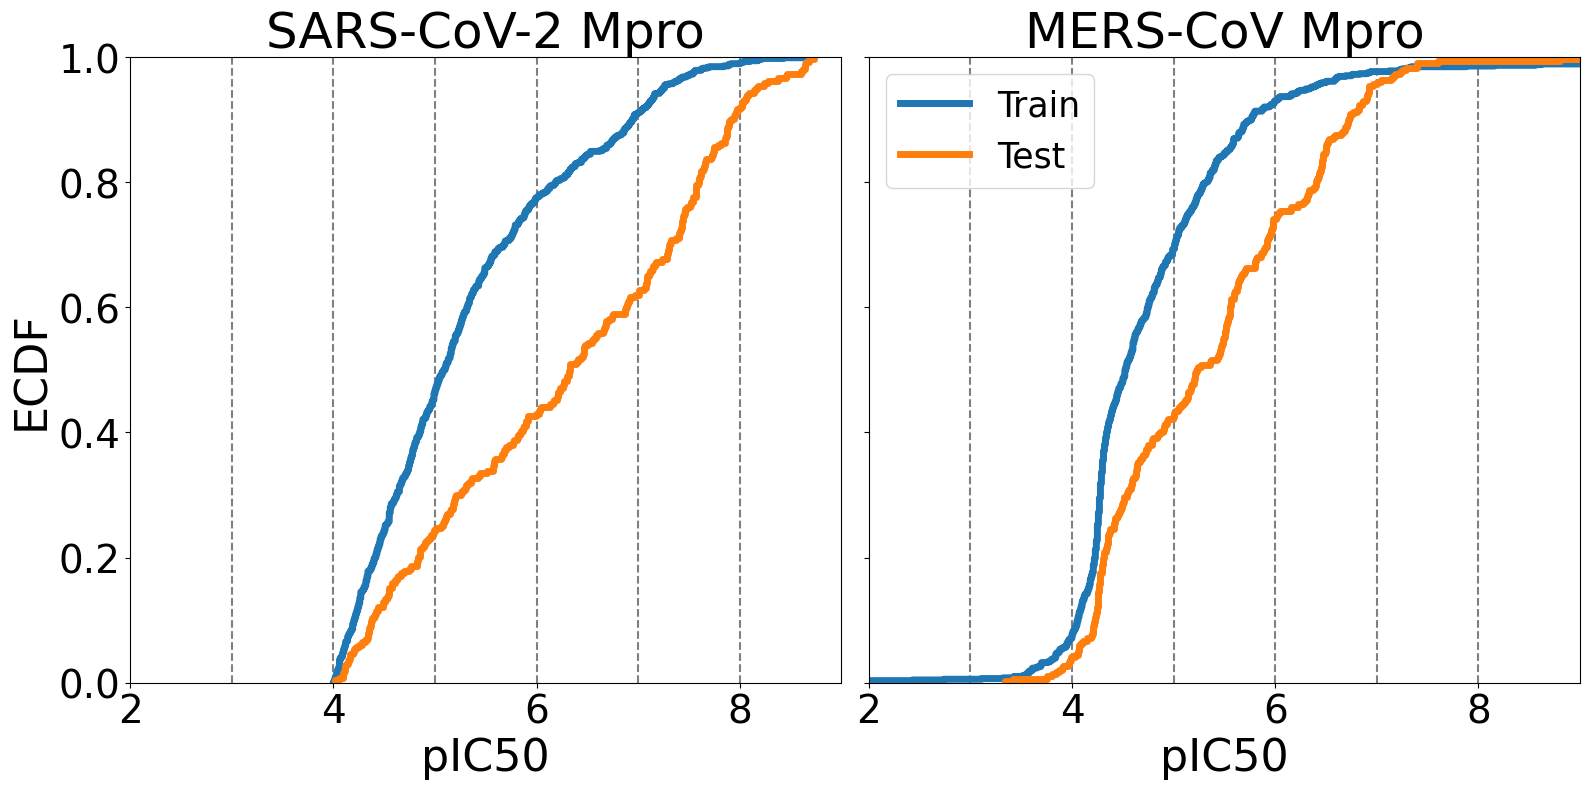

In [36]:
import matplotlib.pyplot as plt

lists = [(potency_train_sars2, potency_test_sars2), (potency_train_mers, potency_test_mers)]
labels = ['SARS-CoV-2 Mpro', 'MERS-CoV Mpro']
axlabels = ["pIC50", "pIC50"]

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)  # Double the size

for ax, data, label, axlabel in zip(axes, lists, labels, axlabels):
    train, test = data

    ax.ecdf(train, linewidth=5, label="Train")  # Double the line width
    ax.ecdf(test, linewidth=5, label="Test")  # Double the line width

    ax.set_title(label, fontsize=36)
    ax.set_xlabel(axlabel, fontsize=32)
    ax.tick_params(axis='both', which='major', labelsize=28)
    ax.set_xlim(2,9)
    for y in [3, 4, 5, 6, 7, 8]:
        ax.axvline(y, zorder=-1, ls="--", color="gray")
axes[0].set_ylabel('ECDF', fontsize=32)

plt.legend(prop={'size': 25}, loc=2)
plt.tight_layout()
plt.savefig("potency_dynamic_range.png", dpi=300)
plt.show()

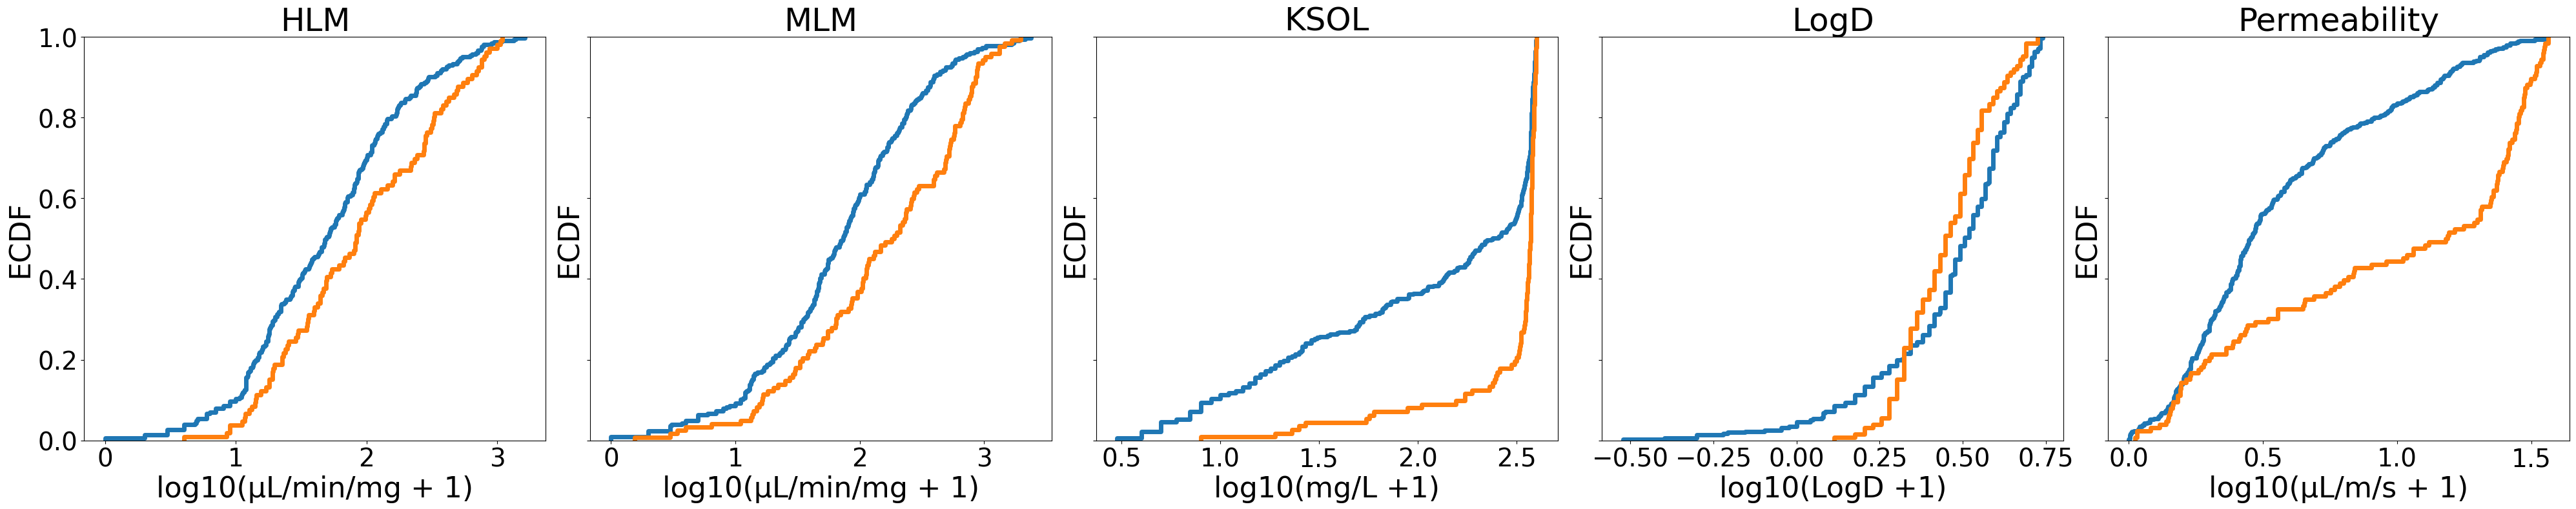

In [44]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt

lists = [(hlm_train, hlm_test), (mlm_train, mlm_test), (ksol_train, ksol_test), (logd_train,logd_test),  (perm_train, perm_test)]
labels = ['HLM', 'MLM', 'KSOL', 'LogD', 'Permeability']
axlabels = [u"log10(\u03bcL/min/mg + 1)", u"log10(\u03bcL/min/mg + 1)", "log10(mg/L +1)" , "log10(LogD +1)", u"log10(\u03bcL/m/s + 1)"]

fig, axes = plt.subplots(1, 5, figsize=(40, 8), sharey=True)  # Double the size

for ax, data, label, axlabel in zip(axes, lists, labels, axlabels):
    train, test = data
    train_log = np.log10(train+1)
    test_log = np.log10(test+1)
    ax.ecdf(train_log, linewidth=5)  # Double the line width
    ax.ecdf(test_log, linewidth=5)  # Double the line width

    ax.set_title(label, fontsize=36)
    ax.set_xlabel(axlabel, fontsize=32)
    ax.set_ylabel('ECDF', fontsize=32)
    ax.tick_params(axis='both', which='major', labelsize=28)

plt.tight_layout()
plt.savefig("admet_endpoints_log10.png", dpi=300)
plt.show()